## TS4

Comenzaremos con la generacion de la siguiente senal:

$$ x(k) = a_0 \cdot sen(\Omega_1 \cdot n) + n_a(n) $$

siendo

$$ a_0 = \sqrt{2} $$

(amplitud que normaliza la potencia de la senoidal: $P_S = \frac{a_0^2}{2} = 1$ W)

$$ \Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N} $$

$$ \Omega_0 = \frac{\pi}{2} $$

siendo la variable aleatoria definida por la siguiente distribucion de probabilidad

$$ f_r \sim \mathcal{U}(-2,\, 2) $$

$$ n_a \sim \mathcal{N}(0,\, \sigma^2) $$

In [56]:
import numpy as np
import matplotlib.pyplot as plt


# params
fs = 1000 # Hz
N  = 1000  # muestras

a0  = np.sqrt(2)      # potencia unitaria: Ps = a0^2/2 = 1 W
Omega0 = np.pi / 2

SNR_dB = 10  # a definir por consigna
sigma2 = (a0**2 / 2) / 10**(SNR_dB/10)   # potencia del ruido = 1/10^(SNR/10)

np.random.seed(42)

# variable aleatoria fr
fr = np.random.uniform(-2, 2)
Omega1 = Omega0 + fr * (2*np.pi / N)

# senal
nn = np.arange(N) # indice de muestra

na = np.random.normal(0, np.sqrt(sigma2), N)
xx = a0 * np.sin(Omega1 * nn) + na

print(f'fr = {fr:.4f}   Omega1 = {Omega1:.6f} rad/muestra   f1 = {Omega1/(2*np.pi)*fs:.4f} Hz')

fr = -0.5018   Omega1 = 1.567643 rad/muestra   f1 = 249.4982 Hz


### Desparramo espectral

La DFT de una senoidal ventaneada con rectangular es el kernel de Dirichlet (la "sinc" periodica) centrado en $f_1$. Como $f_r \sim \mathcal{U}(-2,2)$ y $\Delta f = f_S/N$, el pico siempre cae dentro de la banda $f_0 \pm 2\Delta f$.

Para ver la forma de la sinc hay que **interpolar la DTFT con zero-padding**: la DFT de $N$ puntos solo la muestrea cada $\Delta f$, y en $\pm 2\Delta f$ eso son apenas 5 muestras.

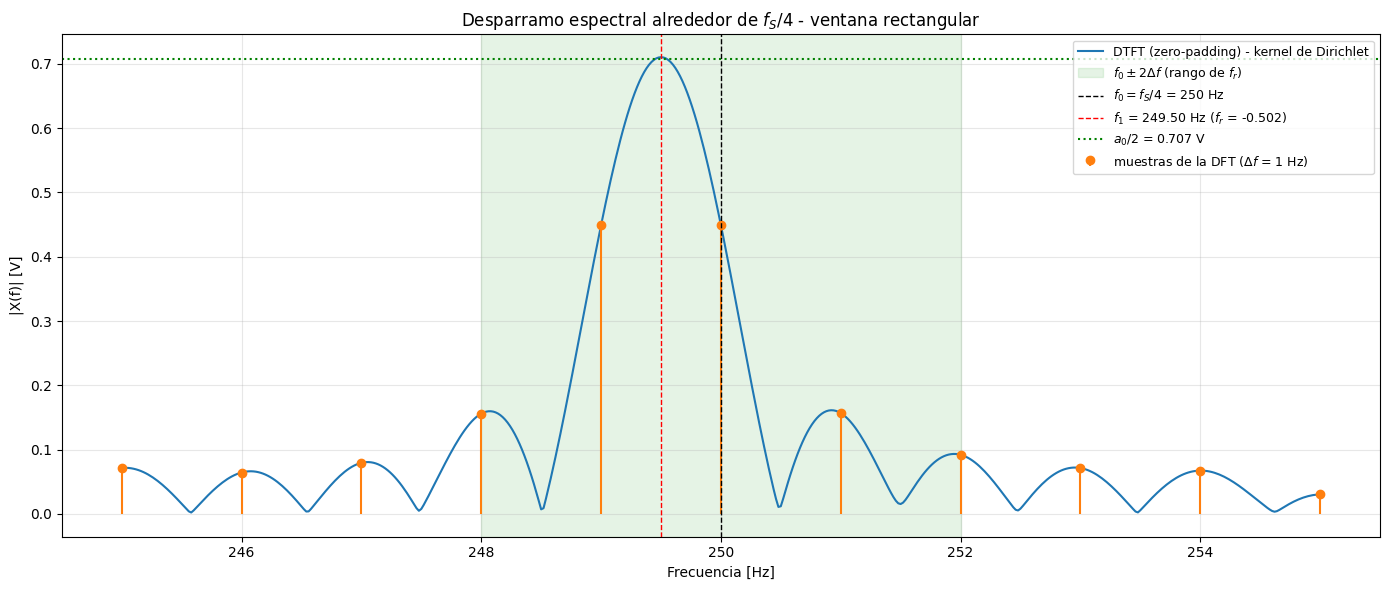

In [57]:
f0 = fs / 4  # 250 Hz -> bin N/4
f1 = Omega1 / (2*np.pi) * fs # frecuencia real, desintonizada
df = fs / N  # 1 Hz

# DTFT interpolada por zero-padding
Npad = 50 * N
ff_p = np.arange(Npad) * fs / Npad
XX_p = np.abs(np.fft.fft(xx, Npad)) / N

# DFT cruda: las muestras que realmente ve el estimador
ff_d = np.arange(N) * df
XX_d = np.abs(np.fft.fft(xx)) / N

# zoom de +/- 5 df alrededor de f0
mp = (ff_p >= f0 - 5*df) & (ff_p <= f0 + 5*df)
md_ = (ff_d >= f0 - 5*df) & (ff_d <= f0 + 5*df)

plt.figure(figsize=(14, 6))
plt.plot(ff_p[mp], XX_p[mp], lw=1.5, label='DTFT (zero-padding) - kernel de Dirichlet')
plt.stem(ff_d[md_], XX_d[md_], linefmt='C1-', markerfmt='C1o', basefmt=' ',
         label='muestras de la DFT ($\\Delta f$ = 1 Hz)')

plt.axvspan(f0 - 2*df, f0 + 2*df, color='C2', alpha=0.12,
            label='$f_0 \\pm 2\\Delta f$ (rango de $f_r$)')
plt.axvline(f0, color='k', linestyle='--', lw=1, label=f'$f_0 = f_S/4$ = {f0:.0f} Hz')
plt.axvline(f1, color='r', linestyle='--', lw=1, label=f'$f_1$ = {f1:.2f} Hz ($f_r$ = {fr:.3f})')
plt.axhline(a0/2, color='g', linestyle=':', lw=1.5, label=f'$a_0/2$ = {a0/2:.3f} V')

plt.title('Desparramo espectral alrededor de $f_S/4$ - ventana rectangular')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|X(f)| [V]')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### Tanda de 200 realizaciones

Hasta aca trabajamos con **una sola** realizacion (un unico valor de $f_r$). Para poder estimar
amplitud y frecuencia hace falta una **tanda de $R = 200$ experimentos**, cada uno con su propio
$f_r \sim \mathcal{U}(-2,\,2)$ y su propio ruido.

Todo se arma de una sola vez como una matriz de $N \times R$, aprovechando *broadcasting*:

$$ \mathbf{X} = a_0 \cdot sen(\mathbf{n} \cdot \mathbf{\Omega_1}) + \mathbf{N_a} $$

donde $\mathbf{n}$ es un vector columna ($N \times 1$) y $\mathbf{\Omega_1}$ un vector fila
($1 \times R$). Cada **columna** es una realizacion distinta.

In [58]:
R = 200  # cantidad de realizaciones

np.random.seed(42)

# una fr distinta por realizacion -> vector fila (1 x R)
fr_v = np.random.uniform(-2, 2, size=(1, R)) # ya le da el formato matriz en el size
om1_v = Omega0 + fr_v * (2*np.pi / N) # 1 x R
f1_v  = om1_v / (2*np.pi) * fs # frecuencia real de cada senoidal [Hz]

# indice de muestra como vector columna (N x 1) cambiar dimension de 0 a 1 para que deje de ser vector
nn_c = np.arange(N).reshape(N, 1)

# ruido independiente para cada realizacion (N x R)
Na = np.random.normal(0, np.sqrt(sigma2), size=(N, R))

# matriz de senales: cada COLUMNA es una realizacion
XX_M = a0 * np.sin(nn_c * om1_v) + Na # (N x 1) * (1 x R) -> N x R

print(f'XX_M.shape = {XX_M.shape}   (N muestras x R realizaciones)')
print(f'fr  en [{fr_v.min():.3f}, {fr_v.max():.3f}]')
print(f'f1  en [{f1_v.min():.3f}, {f1_v.max():.3f}] Hz   (f0 = {f0:.0f} Hz, df = {df:.0f} Hz)')

XX_M.shape = (1000, 200)   (N muestras x R realizaciones)
fr  en [-1.978, 1.948]
f1  en [248.022, 251.948] Hz   (f0 = 250 Hz, df = 1 Hz)


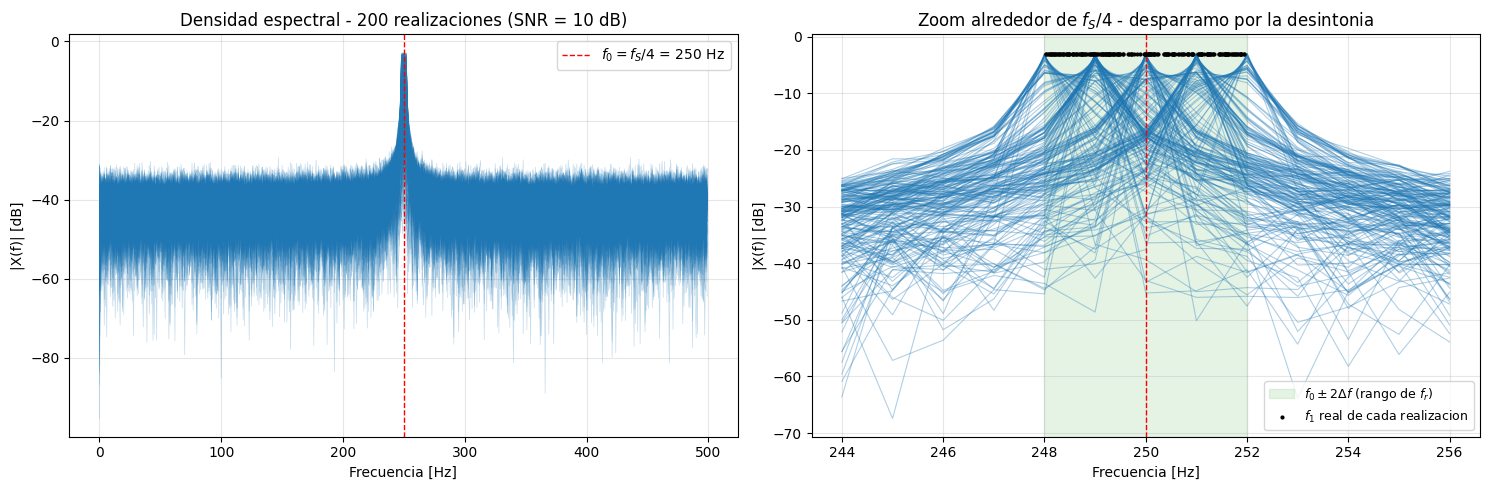

In [59]:
# DFT de todas las realizaciones de una: FFT por columnas (axis=0)
ff = np.arange(N) * df
XF_M = np.fft.fft(XX_M, axis=0) / N
XF_dB = 20 * np.log10(np.abs(XF_M) + 1e-12)

bfr = N // 2  # solo media banda (hasta fs/2)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# --- espectro completo: las 200 superpuestas ---
ax[0].plot(ff[:bfr], XF_dB[:bfr, :], lw=0.5, alpha=0.25, color='C0')
ax[0].axvline(f0, color='r', ls='--', lw=1, label=f'$f_0 = f_S/4$ = {f0:.0f} Hz')
ax[0].set_title(f'Densidad espectral - {R} realizaciones (SNR = {SNR_dB} dB)')
ax[0].set_xlabel('Frecuencia [Hz]')
ax[0].set_ylabel('|X(f)| [dB]')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# --- zoom: se ve como cada realizacion cae en un bin distinto ---
mz = (ff >= f0 - 6*df) & (ff <= f0 + 6*df)
ax[1].plot(ff[mz], XF_dB[mz, :], lw=0.8, alpha=0.35, color='C0')
ax[1].axvspan(f0 - 2*df, f0 + 2*df, color='C2', alpha=0.12,
              label='$f_0 \\pm 2\\Delta f$ (rango de $f_r$)')
ax[1].axvline(f0, color='r', ls='--', lw=1)
ax[1].plot(f1_v.ravel(), np.full(R, 20*np.log10(a0/2)), 'k.', ms=4,
           label='$f_1$ real de cada realizacion')
ax[1].set_title('Zoom alrededor de $f_S/4$ - desparramo por la desintonia')
ax[1].set_xlabel('Frecuencia [Hz]')
ax[1].set_ylabel('|X(f)| [dB]')
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Estimacion con ventanas

Para cada una de las ventanas **rectangular (sin ventana), flattop, Blackman-Harris y Hann** se multiplica cada realizacion por la ventana $w(n)$ y se calculan dos estimadores:

$$ \hat{a}_1 = \frac{2\,|X_w(\Omega_0)|}{\sum_n w(n)} $$

(amplitud leida en el bin **fijo** $k_0 = N/4$. Dividir por $\sum w$ compensa la ganancia coherente de cada ventana, asi con $f_r = 0$ y sin ruido da exactamente $a_0$)

$$ \hat{\Omega}_1 = \frac{2\pi}{N}\,\underset{k}{\arg\max}\,\{|X_w[k]|\} $$

Con las $R = 200$ realizaciones se estiman sesgo y varianza:

$$ s_a = \overline{\hat a_1} - a_0 \qquad v_a = \frac{1}{R}\sum_{j=1}^{R}\left(\hat a_{1,j} - \overline{\hat a_1}\right)^2 $$

$$ s_\Omega = \overline{\hat\Omega_{1,j} - \Omega_{1,j}} \qquad v_\Omega = \mathrm{var}\{\hat\Omega_{1,j} - \Omega_{1,j}\} $$

En frecuencia se compara contra el $\Omega_1$ real de **cada** realizacion, porque cambia de una a otra.

Antes de estimar conviene mirar el espectro de cada ventana: como $\hat a_1$ se lee siempre en $k_0$ y la senoidal esta corrida $f_r$ bins, **el valor de la curva en $f_r$ es la atenuacion que sufre el estimador de amplitud** (sin ruido). La franja verde es todo el rango posible de $f_r$.

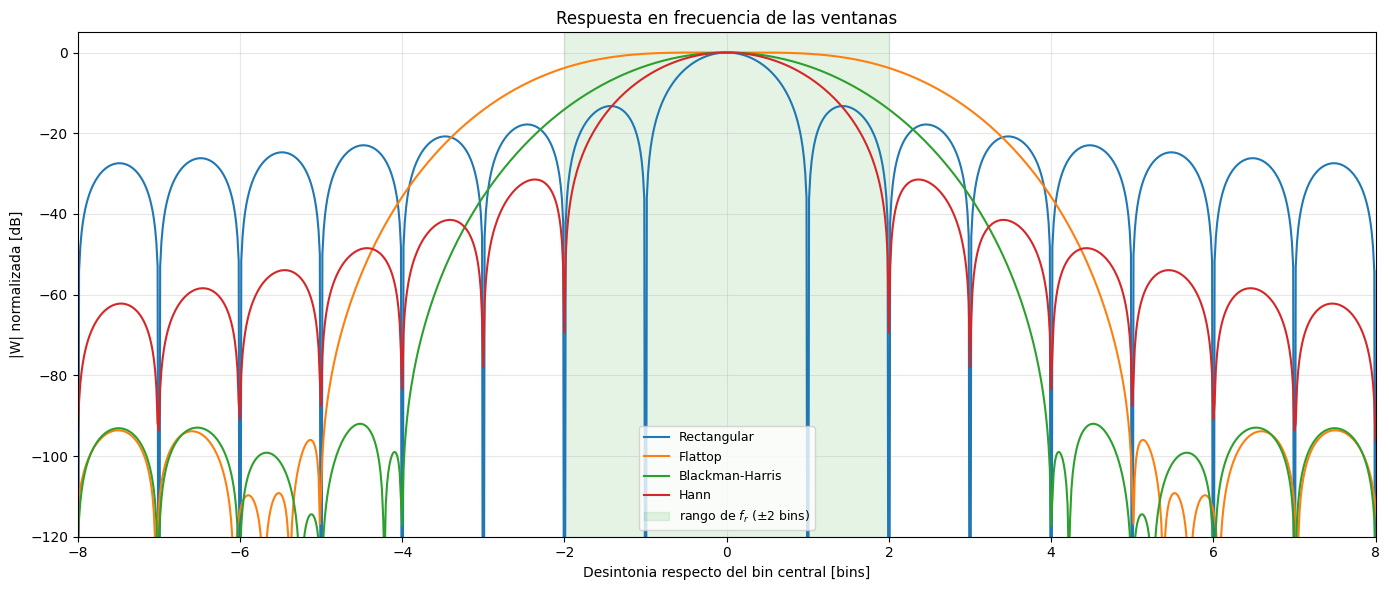

In [60]:
from scipy.signal import windows as win

ventanas = {
    'Rectangular':     win.boxcar(N),
    'Flattop':         win.flattop(N),
    'Blackman-Harris': win.blackmanharris(N),
    'Hann':            win.hann(N),
}

# espectro de cada ventana con mucho zero-padding, normalizado a 0 dB en el pico
Npad_w = 64 * N
bins_w = np.fft.fftshift(np.fft.fftfreq(Npad_w, d=1/N))  # eje en bins (multiplos de df)

plt.figure(figsize=(14, 6))
for nombre, w in ventanas.items():
    W = np.fft.fftshift(np.abs(np.fft.fft(w, Npad_w)))
    plt.plot(bins_w, 20*np.log10(W / W.max() + 1e-12), lw=1.5, label=nombre)

plt.axvspan(-2, 2, color='C2', alpha=0.12, label='rango de $f_r$ ($\\pm 2$ bins)')
plt.title('Respuesta en frecuencia de las ventanas')
plt.xlabel('Desintonia respecto del bin central [bins]')
plt.ylabel('|W| normalizada [dB]')
plt.xlim(-8, 8)
plt.ylim(-120, 5)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', fontsize=9)
plt.tight_layout()
plt.show()

In [61]:
def generar_tanda(SNR_dB, R=200, seed=42):
    """Matriz N x R de realizaciones (misma receta que arriba) y el Omega1 real de cada una."""
    np.random.seed(seed)
    sigma2 = (a0**2 / 2) / 10**(SNR_dB/10)
    fr_v  = np.random.uniform(-2, 2, size=(1, R))
    om1_v = Omega0 + fr_v * (2*np.pi / N)
    Na    = np.random.normal(0, np.sqrt(sigma2), size=(N, R))
    return a0 * np.sin(nn_c * om1_v) + Na, om1_v.ravel()


def estimar(XX, w):
    """Estimadores de amplitud y frecuencia para todas las columnas de XX con la ventana w."""
    Xw = np.fft.fft(XX * w.reshape(N, 1), axis=0)  # ventaneo por broadcasting: (N x R) * (N x 1)
    k0 = N // 4                                     # bin de Omega0 = pi/2
    a_est  = 2 * np.abs(Xw[k0, :]) / np.sum(w)
    om_est = np.argmax(np.abs(Xw[:N//2, :]), axis=0) * 2*np.pi / N
    return a_est, om_est


SNRs = [3, 10]  # dB
resultados = {}

for snr in SNRs:
    XX, om1 = generar_tanda(snr, R)
    for nombre, w in ventanas.items():
        a_est, om_est = estimar(XX, w)
        err_om = om_est - om1  # error contra el Omega1 real de cada realizacion
        resultados[(snr, nombre)] = dict(
            a_est=a_est, err_om=err_om,
            sa=np.mean(a_est) - a0, va=np.var(a_est),
            so=np.mean(err_om),     vo=np.var(err_om))

In [62]:
b = N / (2*np.pi)  # rad/muestra -> bins (1 bin = 2pi/N rad/muestra)

for snr in SNRs:
    print(f'\nSNR = {snr} dB   (a0 = {a0:.4f} V, R = {R} realizaciones)')
    print(f'{"Ventana":<16} | {"s_a [V]":>9} | {"v_a [V^2]":>9} | {"s_Omega [bins]":>14} | {"v_Omega [bins^2]":>16}')
    print('-' * 76)
    for nombre in ventanas:
        r = resultados[(snr, nombre)]
        print(f'{nombre:<16} | {r["sa"]:>+9.4f} | {r["va"]:>9.2e} | {r["so"]*b:>+14.4f} | {r["vo"]*b**2:>16.4f}')


SNR = 3 dB   (a0 = 1.4142 V, R = 200 realizaciones)
Ventana          |   s_a [V] | v_a [V^2] | s_Omega [bins] | v_Omega [bins^2]
----------------------------------------------------------------------------
Rectangular      |   -0.9336 |  1.90e-01 |        -0.0160 |           0.0838
Flattop          |   -0.1248 |  2.51e-02 |        -0.0660 |           0.1719
Blackman-Harris  |   -0.5095 |  1.33e-01 |        -0.0010 |           0.0859
Hann             |   -0.7244 |  2.22e-01 |        -0.0110 |           0.0842

SNR = 10 dB   (a0 = 1.4142 V, R = 200 realizaciones)
Ventana          |   s_a [V] | v_a [V^2] | s_Omega [bins] | v_Omega [bins^2]
----------------------------------------------------------------------------
Rectangular      |   -0.9364 |  1.89e-01 |        -0.0160 |           0.0838
Flattop          |   -0.1253 |  2.16e-02 |        -0.0310 |           0.1295
Blackman-Harris  |   -0.5109 |  1.31e-01 |        -0.0160 |           0.0840
Hann             |   -0.7290 |  2.24e-01 |    

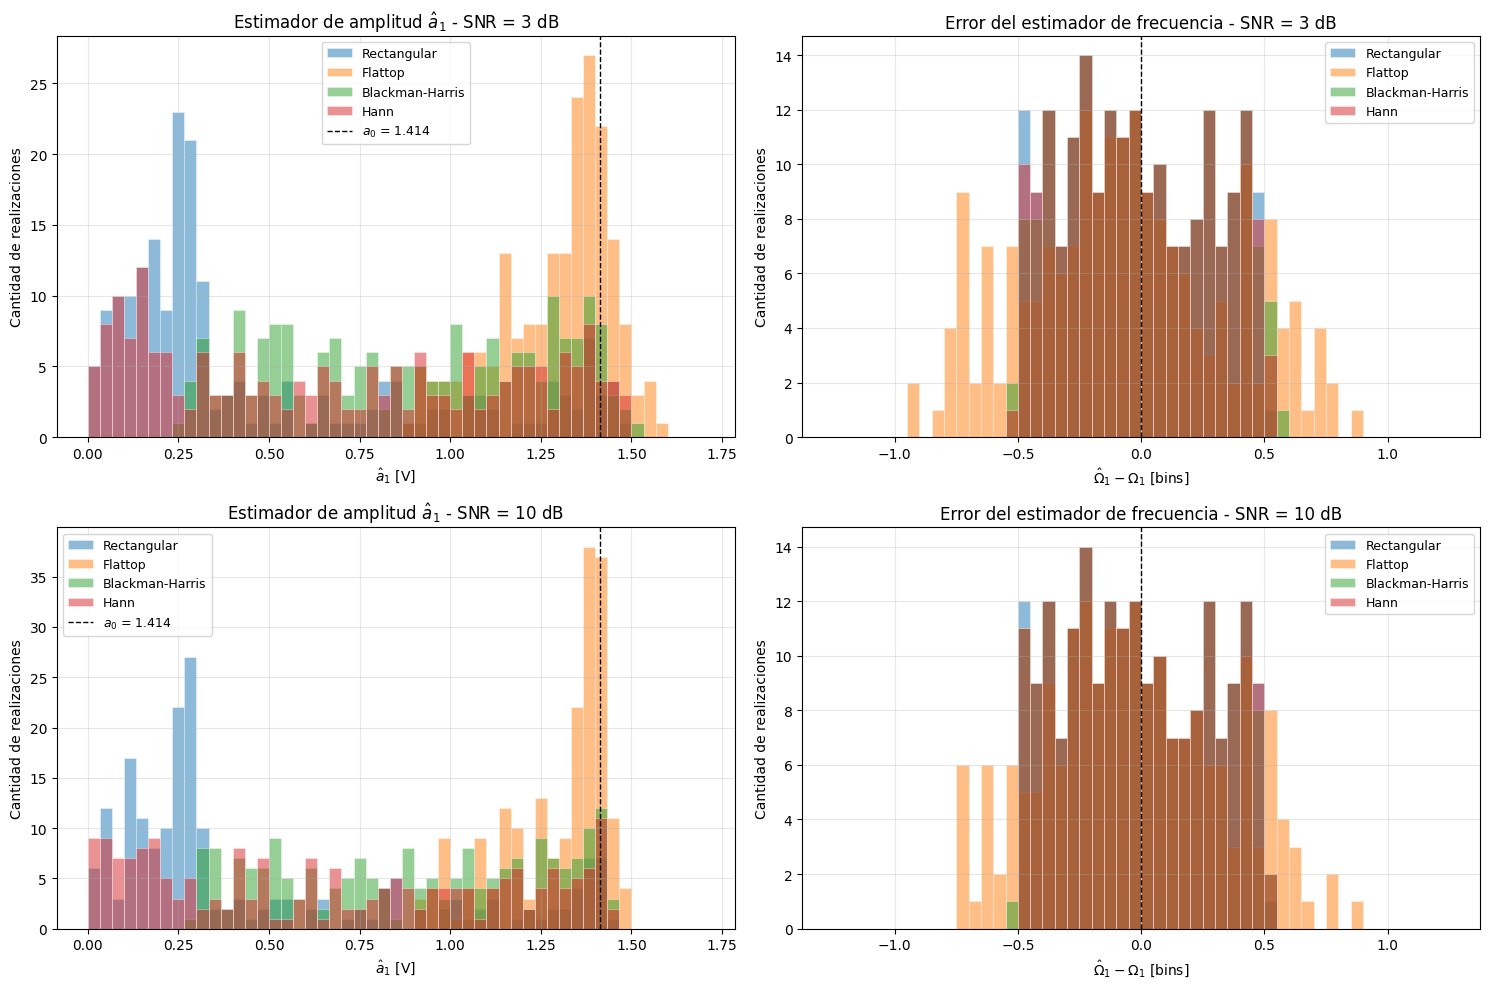

In [63]:
bins_a = np.linspace(0, 1.7, 52)
bins_o = np.arange(-1.25, 1.30, 0.05)  # error de frecuencia en bins
estilo = dict(alpha=0.5, edgecolor='white', linewidth=0.5)

fig, ax = plt.subplots(len(SNRs), 2, figsize=(15, 5*len(SNRs)))

for i, snr in enumerate(SNRs):
    for nombre in ventanas:
        r = resultados[(snr, nombre)]
        ax[i, 0].hist(r['a_est'], bins=bins_a, label=nombre, **estilo)
        ax[i, 1].hist(r['err_om'] * N/(2*np.pi), bins=bins_o, label=nombre, **estilo)

    ax[i, 0].axvline(a0, color='k', ls='--', lw=1, label=f'$a_0$ = {a0:.3f}')
    ax[i, 0].set_title(f'Estimador de amplitud $\\hat a_1$ - SNR = {snr} dB')
    ax[i, 0].set_xlabel('$\\hat a_1$ [V]')

    ax[i, 1].axvline(0, color='k', ls='--', lw=1)
    ax[i, 1].set_title(f'Error del estimador de frecuencia - SNR = {snr} dB')
    ax[i, 1].set_xlabel('$\\hat\\Omega_1 - \\Omega_1$ [bins]')

    for a in ax[i]:
        a.set_ylabel('Cantidad de realizaciones')
        a.grid(True, alpha=0.3)
        a.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Analisis de resultados

**Estimador de amplitud.** Como $\hat a_1$ se lee siempre en el bin fijo $k_0$, todo se explica con el grafico de las ventanas: cada realizacion queda atenuada por $|W(f_r)|$, y como $f_r$ recorre $\pm 2$ bins lo que manda es cuanto cae cada ventana en ese rango.

| Ventana | Atenuacion en $f_r = \pm 1$ | Atenuacion en $f_r = \pm 2$ |
|---|---|---|
| Rectangular | nulo | nulo |
| Hann | -6 dB | ~nulo (-70 dB) |
| Blackman-Harris | -3.3 dB | -14 dB |
| Flattop | -0.3 dB | -3.8 dB |

- **Rectangular**: su lobulo principal mide solo $\pm 1$ bin y tiene nulos en $\pm 1$ y $\pm 2$, asi que muchas realizaciones dan $\hat a_1$ casi nulo. Es la de mayor sesgo ($s_a \approx -0.93$ V).
- **Hann**: el lobulo llega a $\pm 2$ bins, mejora el sesgo ($\approx -0.73$ V) pero $\hat a_1$ queda repartido entre 0 y $a_0$, por eso tiene la **mayor varianza** ($\approx 0.22$ V$^2$).
- **Blackman-Harris**: lobulo de $\pm 4$ bins, en el peor caso cae 14 dB. Sesgo intermedio ($\approx -0.51$ V).
- **Flattop**: el lobulo es practicamente plano en todo el rango de $f_r$, por eso es la **mejor para amplitud**: menor sesgo ($\approx -0.125$ V) y menor varianza ($\approx 0.02$ V$^2$), casi un orden de magnitud menos que las demas.

Casi no hay diferencia entre 3 y 10 dB en $v_a$: con estas ventanas la dispersion de $\hat a_1$ la domina la desintonia $f_r$, no el ruido. La flattop es la unica donde el ruido se nota (0.025 vs 0.022 V$^2$), porque su lobulo ancho junta mas ruido (ancho de banda equivalente de ruido $\approx 3.8$ bins, contra 1 bin de la rectangular).

**Estimador de frecuencia.** El $\arg\max$ solo puede devolver frecuencias de la grilla $2\pi k/N$, entonces el error queda casi uniforme en $\pm 0.5$ bins: sesgo $\approx 0$ y varianza $\approx 1/12 = 0.083$ bins$^2$. Eso es exactamente lo que dan la rectangular, la Hann y la Blackman-Harris ($\approx 0.084$ bins$^2$): el limite lo pone la **resolucion de la DFT** ($\Delta f = f_S/N$), no la ventana ni el ruido. Los sesgos de $\approx \pm 0.01$ bins son compatibles con cero (con 200 realizaciones el desvio de la media es $\sqrt{0.083/200} \approx 0.02$ bins).

La **flattop es la peor en frecuencia** ($v_\Omega \approx 0.17$ bins$^2$ a 3 dB, $0.13$ a 10 dB): la punta de su lobulo es tan plana que los bins vecinos al pico tienen casi la misma magnitud, y con ruido el maximo salta al bin de al lado (errores de hasta $\pm 0.9$ bins). Por eso mejora al subir la SNR.

**Conclusion:** ninguna ventana es la mejor para las dos cosas. Para medir amplitud conviene la flattop; para frecuencia la rectangular, Hann y Blackman-Harris son equivalentes, y para mejorarla haria falta mas resolucion (zero-padding o interpolacion), no otra ventana.

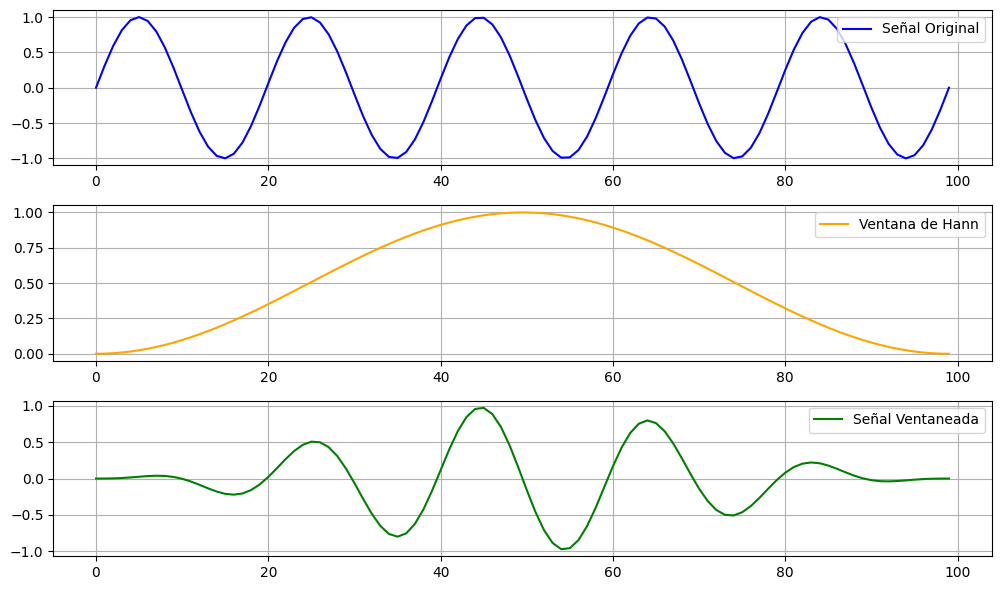

In [64]:
import numpy as np
import scipy.signal.windows as windows
import matplotlib.pyplot as plt

# 1. Crear una señal de ejemplo (una onda senoidal de 100 muestras)
num_muestras = 100
t = np.linspace(0, 1, num_muestras)
senal_original = np.sin(2 * np.pi * 5 * t)  # Seno de 5 Hz

# 2. Generar la función de ventana usando SciPy
# Se pueden usar alternativas como windows.hamming o windows.blackman
ventana = windows.hann(num_muestras) 

# 3. Aplicar el ventaneo (multiplicación elemento a elemento)
senal_ventaneada = senal_original * ventana

# 4. Graficar los resultados
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(senal_original, label="Señal Original", color="blue")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(ventana, label="Ventana de Hann", color="orange")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(senal_ventaneada, label="Señal Ventaneada", color="green")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


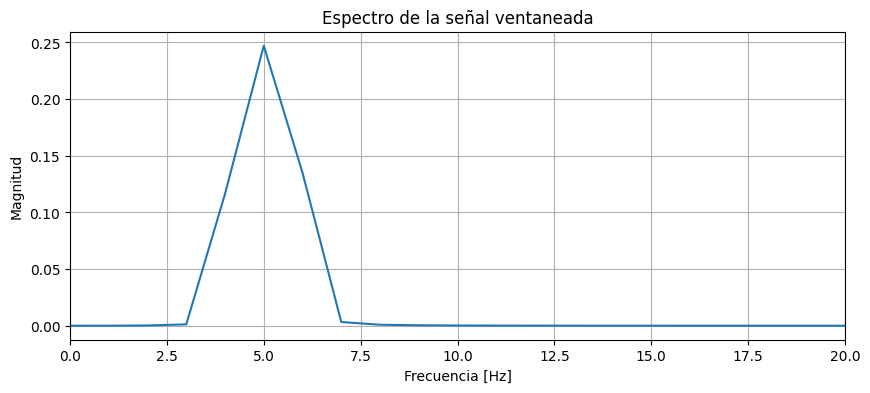

In [65]:
# 5. Calcular la FFT de la señal ventaneada
N = len(senal_ventaneada)
fs = 100  # Frecuencia de muestreo [Hz]

fft_ventaneada = np.fft.fft(senal_ventaneada)
frecuencias = np.fft.fftfreq(N, 1/fs)

# Magnitud de la FFT
magnitud = np.abs(fft_ventaneada) / N

# Nos quedamos con las frecuencias positivas
frecuencias_positivas = frecuencias[:N//2]
magnitud_positiva = magnitud[:N//2]

# 6. Graficar el espectro
plt.figure(figsize=(10, 4))
plt.plot(frecuencias_positivas, magnitud_positiva)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de la señal ventaneada")
plt.grid(True)
plt.xlim(0, 20)
plt.show()

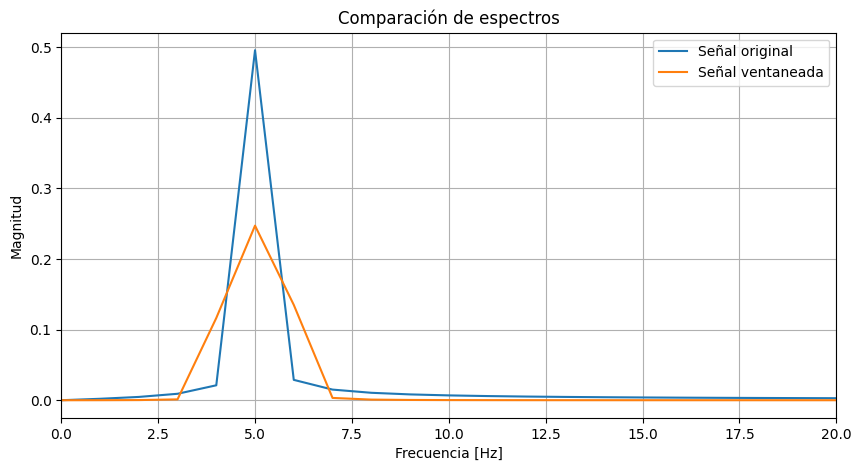

In [66]:
# FFT de la señal original
fft_original = np.fft.fft(senal_original)
magnitud_original = np.abs(fft_original) / N

# Espectro positivo
magnitud_original_positiva = magnitud_original[:N//2]

plt.figure(figsize=(10, 5))

plt.plot(
    frecuencias_positivas,
    magnitud_original_positiva,
    label="Señal original"
)

plt.plot(
    frecuencias_positivas,
    magnitud_positiva,
    label="Señal ventaneada"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación de espectros")
plt.xlim(0, 20)
plt.grid(True)
plt.legend()
plt.show()